<a href="https://colab.research.google.com/github/Limeng-svg/Grounded-PPE-Safety-Copilot/blob/main/notebooks/05_dataset_acquisition_and_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q pandas PyYAML Pillow

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from zipfile import ZipFile
import urllib.request
import shutil

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Grounded-PPE-Safety-Copilot"
)

DATASET_VERSION = "construction_ppe_3class_v1"

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / DATASET_VERSION
)

SOURCE_URL = (
    "https://github.com/ultralytics/assets/"
    "releases/download/v0.0.0/"
    "construction-ppe.zip"
)

SOURCE_ZIP = Path(
    "/content/construction-ppe.zip"
)

SOURCE_ROOT = Path(
    "/content/construction-ppe-source"
)

RUN_ID = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%SZ")

BUILD_ROOT = Path(
    f"/content/{DATASET_VERSION}_build_{RUN_ID}"
)

assert not OUTPUT_ROOT.exists(), (
    f"{OUTPUT_ROOT} already exists.\n"
    "If this is a new version, change DATASET_VERSION."
)

PROJECT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

if not SOURCE_ZIP.exists():
    print("Downloading Construction-PPE (~178 MB)...")
    urllib.request.urlretrieve(
        SOURCE_URL,
        SOURCE_ZIP,
    )

if not (SOURCE_ROOT / "images").exists():
    SOURCE_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    with ZipFile(SOURCE_ZIP) as archive:
        resolved_root = SOURCE_ROOT.resolve()

        for member in archive.infolist():
            destination = (
                SOURCE_ROOT / member.filename
            ).resolve()

            assert (
                destination == resolved_root
                or resolved_root
                in destination.parents
            ), "Unsafe path found in ZIP."

        archive.extractall(SOURCE_ROOT)

print("Source dataset:", SOURCE_ROOT)
print("Download and extraction complete.")

Source dataset: /content/construction-ppe-source
Download and extraction complete.


In [ ]:
from collections import Counter
import hashlib
import math

import pandas as pd
from PIL import Image

SOURCE_TO_TARGET = {
    6: 0,  # Person -> person
    0: 1,  # helmet -> hard_hat
    2: 2,  # vest -> safety_vest
}

TARGET_NAMES = {
    0: "person",
    1: "hard_hat",
    2: "safety_vest",
}

IMAGE_SUFFIXES = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
}

SPLITS = (
    "train",
    "val",
    "test",
)


def file_sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for chunk in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


BUILD_ROOT.mkdir(
    parents=True,
    exist_ok=False,
)

records = []
issues = []
orphan_labels = []

for split in SPLITS:
    source_images = (
        SOURCE_ROOT / "images" / split
    )
    source_labels = (
        SOURCE_ROOT / "labels" / split
    )

    target_images = (
        BUILD_ROOT / "images" / split
    )
    target_labels = (
        BUILD_ROOT / "labels" / split
    )

    target_images.mkdir(
        parents=True,
        exist_ok=True,
    )

    target_labels.mkdir(
        parents=True,
        exist_ok=True,
    )

    image_paths = sorted([
        path
        for path in source_images.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_SUFFIXES
        )
    ])

    image_stems = {
        path.stem
        for path in image_paths
    }

    for label_path in source_labels.rglob(
        "*.txt"
    ):
        if label_path.stem not in image_stems:
            orphan_labels.append({
                "split": split,
                "label": label_path.name,
            })

    for image_path in image_paths:
        relative_image = image_path.relative_to(
            source_images
        )

        label_path = (
            source_labels
            / relative_image.with_suffix(".txt")
        )

        if not label_path.exists():
            issues.append({
                "split": split,
                "image": str(relative_image),
                "issue": "missing_label",
            })
            continue

        try:
            with Image.open(image_path) as image:
                width, height = image.size
                image.verify()
        except Exception as error:
            issues.append({
                "split": split,
                "image": str(relative_image),
                "issue": f"corrupt_image: {error}",
            })
            continue

        mapped_lines = []
        class_counts = Counter()

        source_lines = label_path.read_text(
            encoding="utf-8"
        ).splitlines()

        for line_number, raw_line in enumerate(
            source_lines,
            start=1,
        ):
            if not raw_line.strip():
                continue

            parts = raw_line.split()

            try:
                assert len(parts) == 5

                class_value = float(parts[0])
                assert class_value.is_integer()

                source_class = int(class_value)

                coordinates = [
                    float(value)
                    for value in parts[1:]
                ]

                x_center, y_center, box_w, box_h = (
                    coordinates
                )

                assert all(
                    math.isfinite(value)
                    for value in coordinates
                )

                assert 0 <= x_center <= 1
                assert 0 <= y_center <= 1
                assert 0 < box_w <= 1
                assert 0 < box_h <= 1

            except Exception:
                issues.append({
                    "split": split,
                    "image": str(relative_image),
                    "issue": (
                        f"invalid_label_line_"
                        f"{line_number}"
                    ),
                })
                continue

            if source_class in SOURCE_TO_TARGET:
                target_class = (
                    SOURCE_TO_TARGET[
                        source_class
                    ]
                )

                mapped_lines.append(
                    " ".join([
                        str(target_class),
                        *parts[1:],
                    ])
                )

                class_counts[target_class] += 1

        target_image_path = (
            target_images / relative_image
        )

        target_label_path = (
            target_labels
            / relative_image.with_suffix(".txt")
        )

        target_image_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        target_label_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            image_path,
            target_image_path,
        )

        target_label_path.write_text(
            "\n".join(mapped_lines)
            + ("\n" if mapped_lines else ""),
            encoding="utf-8",
        )

        records.append({
            "split": split,
            "image_name":
                relative_image.as_posix(),
            "width": width,
            "height": height,
            "person_boxes":
                class_counts[0],
            "hard_hat_boxes":
                class_counts[1],
            "safety_vest_boxes":
                class_counts[2],
            "image_sha256":
                file_sha256(image_path),
            "label_sha256":
                file_sha256(
                    target_label_path
                ),
            "source_dataset":
                "Ultralytics Construction-PPE",
            "source_license":
                "AGPL-3.0",
        })

if issues:
    issues_df = pd.DataFrame(issues)
    display(issues_df.head(30))

    raise RuntimeError(
        f"Audit failed with "
        f"{len(issues_df)} issue(s)."
    )

manifest_df = pd.DataFrame(records)

cross_split_duplicates = (
    manifest_df
    .groupby("image_sha256")["split"]
    .nunique()
)

cross_split_duplicates = (
    cross_split_duplicates[
        cross_split_duplicates > 1
    ]
)

assert cross_split_duplicates.empty, (
    "Exact duplicate images were found "
    "across splits."
)

summary_df = (
    manifest_df
    .groupby(
        "split",
        sort=False,
    )
    .agg(
        images=("image_name", "size"),
        person_boxes=("person_boxes", "sum"),
        hard_hat_boxes=(
            "hard_hat_boxes",
            "sum",
        ),
        safety_vest_boxes=(
            "safety_vest_boxes",
            "sum",
        ),
    )
)

display(summary_df)

print(
    "Orphan source labels:",
    len(orphan_labels),
)

,images,person_boxes,hard_hat_boxes,safety_vest_boxes
split,,,,
train,1132,1770,1341,1269
val,143,239,201,171
test,141,236,192,178


Orphan source labels: 10


In [ ]:
import json
import yaml

manifest_df.to_csv(
    BUILD_ROOT / "manifest.csv",
    index=False,
)

summary_df.to_csv(
    BUILD_ROOT / "split_summary.csv",
)

pd.DataFrame(orphan_labels).to_csv(
    BUILD_ROOT / "orphan_source_labels.csv",
    index=False,
)

training_yaml = {
    "path": str(OUTPUT_ROOT),
    "train": "images/train",
    "val": "images/val",
    "names": TARGET_NAMES,
}

final_yaml = {
    **training_yaml,
    "test": "images/test",
}

(BUILD_ROOT / "dataset.yaml").write_text(
    yaml.safe_dump(
        training_yaml,
        sort_keys=False,
    ),
    encoding="utf-8",
)

(
    BUILD_ROOT / "dataset_final.yaml"
).write_text(
    yaml.safe_dump(
        final_yaml,
        sort_keys=False,
    ),
    encoding="utf-8",
)

test_manifest_df = (
    manifest_df[
        manifest_df["split"] == "test"
    ][[
        "image_name",
        "image_sha256",
        "label_sha256",
    ]]
    .sort_values("image_name")
)

test_manifest_df.to_csv(
    BUILD_ROOT
    / "frozen_test_manifest.csv",
    index=False,
)

signature_text = (
    test_manifest_df.to_csv(
        index=False
    )
)

test_signature = hashlib.sha256(
    signature_text.encode("utf-8")
).hexdigest()

(
    BUILD_ROOT
    / "frozen_test_signature.sha256"
).write_text(
    test_signature + "\n",
    encoding="utf-8",
)

dataset_card = {
    "dataset":
        "Ultralytics Construction-PPE",
    "official_url":
        "https://docs.ultralytics.com/"
        "datasets/detect/construction-ppe/",
    "license": "AGPL-3.0",
    "class_mapping": {
        "6 Person": "0 person",
        "0 helmet": "1 hard_hat",
        "2 vest": "2 safety_vest",
    },
    "legacy_mini_eval":
        "development only; not included",
    "test_policy": (
        "Do not use test for model, "
        "prompt, threshold, epoch, or "
        "hyperparameter selection."
    ),
}

(
    BUILD_ROOT / "dataset_card.json"
).write_text(
    json.dumps(
        dataset_card,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

license_path = SOURCE_ROOT / "LICENSE"

if license_path.exists():
    shutil.copy2(
        license_path,
        BUILD_ROOT / "SOURCE_LICENSE",
    )

OUTPUT_ROOT.parent.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copytree(
    BUILD_ROOT,
    OUTPUT_ROOT,
)

print("Dataset saved to:", OUTPUT_ROOT)
print(
    "Frozen test signature:",
    test_signature,
)
print(
    "Use for training:",
    OUTPUT_ROOT / "dataset.yaml",
)
print(
    "Do not use yet:",
    OUTPUT_ROOT / "dataset_final.yaml",
)

Dataset saved to: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/datasets/construction_ppe_3class_v1
Frozen test signature: 36556e6046d9e84ee4632c14f10b9b86b5e2f562677d6bbf070dda67a13332ac
Use for training: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/datasets/construction_ppe_3class_v1/dataset.yaml
Do not use yet: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/datasets/construction_ppe_3class_v1/dataset_final.yaml


train: 1132 images
       1770 person
       1341 hard_hat
       1269 safety_vest

val:   143 images
       239 person
       201 hard_hat
       171 safety_vest

test:  141 images
       236 person
       192 hard_hat
       178 safety_vest

In [ ]:
from pathlib import Path
import pandas as pd

DATASET_ROOT = Path(
    "/content/drive/MyDrive/"
    "Grounded-PPE-Safety-Copilot/"
    "datasets/construction_ppe_3class_v1"
)

# 1. Dataset summary
summary_df = pd.read_csv(
    DATASET_ROOT / "split_summary.csv"
)

print("=== Dataset summary ===")
display(summary_df)

# 2. Orphan source labels
orphan_df = pd.read_csv(
    DATASET_ROOT / "orphan_source_labels.csv"
)

print(
    "Orphan source labels:",
    len(orphan_df),
)

display(orphan_df)

# 3. Frozen test signature
test_signature = (
    DATASET_ROOT
    / "frozen_test_signature.sha256"
).read_text(
    encoding="utf-8"
).strip()

print(
    "Frozen test signature:",
    test_signature,
)

=== Dataset summary ===


,split,images,person_boxes,hard_hat_boxes,safety_vest_boxes
0,train,1132,1770,1341,1269
1,val,143,239,201,171
2,test,141,236,192,178


Orphan source labels: 10


,split,label
0,train,image946(1).txt
1,train,image947(1).txt
2,train,image945(1).txt
3,train,image950(1).txt
4,train,image944(1).txt
5,train,image949(1).txt
6,train,image948(1).txt
7,train,image941(1).txt
8,train,image95(1).txt
9,train,image940(1).txt


Frozen test signature: 36556e6046d9e84ee4632c14f10b9b86b5e2f562677d6bbf070dda67a13332ac


In [ ]:
%pip install -q ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.3 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import urllib.request

import imagehash
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Grounded-PPE-Safety-Copilot"
)

DATASET_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "construction_ppe_3class_v1"
)

REPORT_ROOT = DATASET_ROOT / "reports"
REPORT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

manifest_df = pd.read_csv(
    DATASET_ROOT / "manifest.csv"
)


def calculate_phash(path):
    with Image.open(path) as image:
        return str(
            imagehash.phash(
                image.convert("RGB")
            )
        )


hash_records = []

for row in manifest_df.itertuples():
    image_path = (
        DATASET_ROOT
        / "images"
        / row.split
        / row.image_name
    )

    hash_records.append({
        "split": row.split,
        "image_name": row.image_name,
        "phash": calculate_phash(
            image_path
        ),
    })

hash_df = pd.DataFrame(hash_records)

hash_df.to_csv(
    REPORT_ROOT
    / "perceptual_hashes.csv",
    index=False,
)

hash_rows = hash_df.to_dict(
    orient="records"
)

near_duplicate_records = []

for left_index in range(
    len(hash_rows)
):
    left = hash_rows[left_index]
    left_hash = int(
        left["phash"],
        16,
    )

    for right_index in range(
        left_index + 1,
        len(hash_rows),
    ):
        right = hash_rows[right_index]

        if left["split"] == right["split"]:
            continue

        right_hash = int(
            right["phash"],
            16,
        )

        distance = (
            left_hash ^ right_hash
        ).bit_count()

        if distance <= 8:
            near_duplicate_records.append({
                "left_split":
                    left["split"],
                "left_image":
                    left["image_name"],
                "right_split":
                    right["split"],
                "right_image":
                    right["image_name"],
                "phash_distance":
                    distance,
                "decision": (
                    "AUTO_GROUP"
                    if distance <= 4
                    else "MANUAL_REVIEW"
                ),
            })

near_duplicate_df = pd.DataFrame(
    near_duplicate_records
)

near_duplicate_df.to_csv(
    REPORT_ROOT
    / "cross_split_near_duplicates.csv",
    index=False,
)

auto_group_count = (
    0
    if near_duplicate_df.empty
    else (
        near_duplicate_df["decision"]
        == "AUTO_GROUP"
    ).sum()
)

manual_review_count = (
    0
    if near_duplicate_df.empty
    else (
        near_duplicate_df["decision"]
        == "MANUAL_REVIEW"
    ).sum()
)

print(
    "Cross-split AUTO_GROUP pairs:",
    auto_group_count,
)

print(
    "Cross-split MANUAL_REVIEW pairs:",
    manual_review_count,
)

display(
    near_duplicate_df.head(30)
)

Cross-split AUTO_GROUP pairs: 38
Cross-split MANUAL_REVIEW pairs: 158


,left_split,left_image,right_split,right_image,phash_distance,decision
0,train,image1001.jpg,test,image999.jpg,8,MANUAL_REVIEW
1,train,image1002.jpg,test,image1003.jpg,2,AUTO_GROUP
2,train,image1004.jpg,test,image1003.jpg,2,AUTO_GROUP
3,train,image1011.jpg,val,image1010.jpg,2,AUTO_GROUP
4,train,image1018.jpg,test,image1019.jpg,8,MANUAL_REVIEW
5,train,image102.jpg,test,image160.jpg,8,MANUAL_REVIEW
6,train,image1020.jpg,test,image1019.jpg,2,AUTO_GROUP
7,train,image1021.jpg,test,image1023.jpg,8,MANUAL_REVIEW
8,train,image1022.jpg,test,image1023.jpg,6,MANUAL_REVIEW
9,train,image1025.jpg,val,image31.jpg,6,MANUAL_REVIEW


In [ ]:
LEGACY_NAMES = [
    "easy_01.jpg",
    "easy_02.jpg",
    "easy_03.jpg",
    "easy_04.jpg",
    "hard_01.jpg",
    "hard_02.jpg",
    "hard_03.jpg",
    "hard_04.jpg",
    "violation_01.jpg",
    "violation_02.jpg",
    "violation_03.jpg",
    "violation_04.jpg",
]

LEGACY_ROOT = (
    PROJECT_ROOT
    / "data"
    / "mini_eval"
    / "images"
)

if not LEGACY_ROOT.exists():
    LEGACY_ROOT = Path(
        "/content/legacy_mini_eval"
    )

    LEGACY_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    raw_base = (
        "https://raw.githubusercontent.com/"
        "Limeng-svg/"
        "Grounded-PPE-Safety-Copilot/"
        "main/data/mini_eval/images"
    )

    for image_name in LEGACY_NAMES:
        destination = (
            LEGACY_ROOT / image_name
        )

        if not destination.exists():
            urllib.request.urlretrieve(
                f"{raw_base}/{image_name}",
                destination,
            )

legacy_hashes = []

for image_path in sorted(
    LEGACY_ROOT.glob("*")
):
    if image_path.suffix.lower() not in {
        ".jpg", ".jpeg", ".png", ".webp"
    }:
        continue

    legacy_hashes.append({
        "legacy_image":
            image_path.name,
        "phash":
            calculate_phash(image_path),
    })

legacy_overlap_records = []

for legacy in legacy_hashes:
    legacy_hash = int(
        legacy["phash"],
        16,
    )

    for current in hash_rows:
        current_hash = int(
            current["phash"],
            16,
        )

        distance = (
            legacy_hash ^ current_hash
        ).bit_count()

        if distance <= 8:
            legacy_overlap_records.append({
                "legacy_image":
                    legacy["legacy_image"],
                "dataset_split":
                    current["split"],
                "dataset_image":
                    current["image_name"],
                "phash_distance":
                    distance,
            })

legacy_overlap_df = pd.DataFrame(
    legacy_overlap_records
)

legacy_overlap_df.to_csv(
    REPORT_ROOT
    / "legacy_overlap.csv",
    index=False,
)

print(
    "Legacy mini-eval overlap pairs:",
    len(legacy_overlap_df),
)

display(
    legacy_overlap_df.head(20)
)

Legacy mini-eval overlap pairs: 0


""


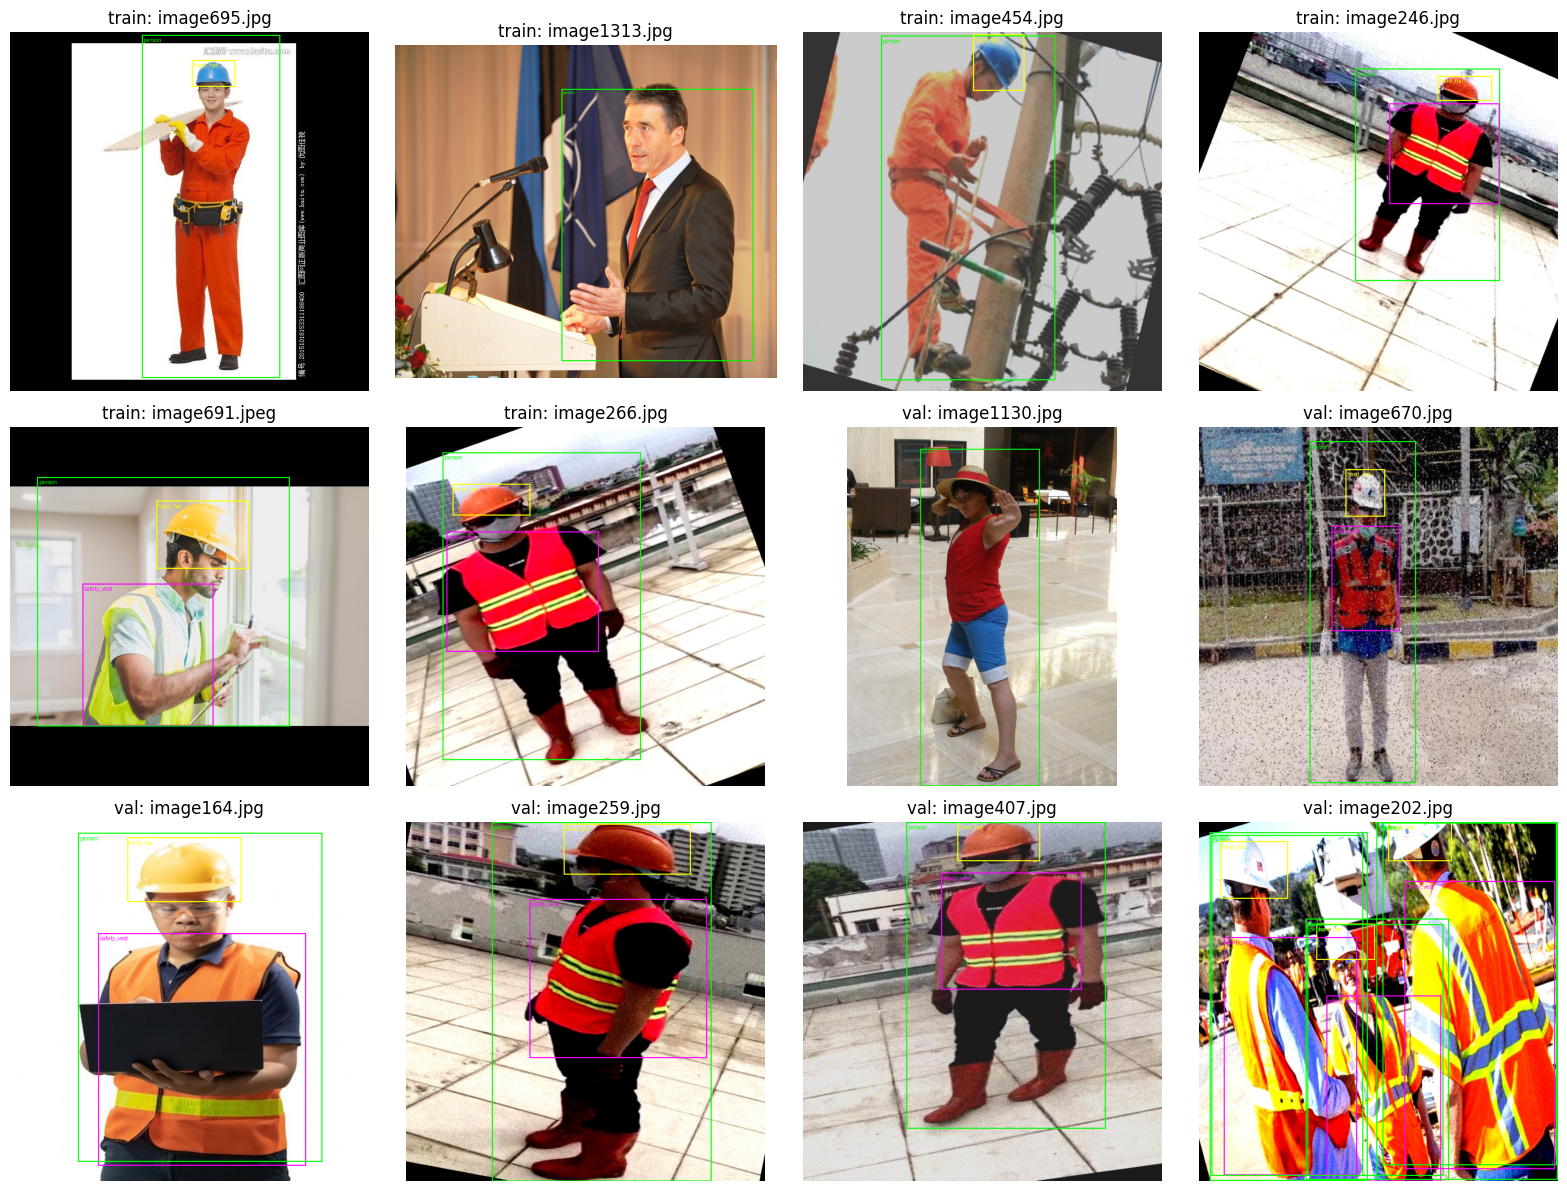

Preview saved to: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/datasets/construction_ppe_3class_v1/reports/train_val_label_preview.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageDraw

CLASS_NAMES = {
    0: "person",
    1: "hard_hat",
    2: "safety_vest",
}

COLORS = {
    0: "lime",
    1: "yellow",
    2: "magenta",
}


def draw_yolo_labels(
    image_path,
    label_path,
):
    image = Image.open(
        image_path
    ).convert("RGB")

    draw = ImageDraw.Draw(image)
    width, height = image.size

    lines = label_path.read_text(
        encoding="utf-8"
    ).splitlines()

    for line in lines:
        if not line.strip():
            continue

        class_id, xc, yc, bw, bh = (
            map(float, line.split())
        )

        class_id = int(class_id)

        x1 = (xc - bw / 2) * width
        y1 = (yc - bh / 2) * height
        x2 = (xc + bw / 2) * width
        y2 = (yc + bh / 2) * height

        draw.rectangle(
            [x1, y1, x2, y2],
            outline=COLORS[class_id],
            width=max(
                2,
                min(width, height) // 250,
            ),
        )

        draw.text(
            (x1 + 3, y1 + 3),
            CLASS_NAMES[class_id],
            fill=COLORS[class_id],
        )

    return image


review_pool = manifest_df[
    manifest_df["split"].isin(
        ["train", "val"]
    )
].copy()

selected_rows = []

for split in ["train", "val"]:
    split_df = review_pool[
        review_pool["split"] == split
    ]

    for column in [
        "person_boxes",
        "hard_hat_boxes",
        "safety_vest_boxes",
    ]:
        candidates = split_df[
            split_df[column] > 0
        ]

        selected_rows.append(
            candidates.sample(
                n=2,
                random_state=(
                    20260908
                    + len(selected_rows)
                ),
            )
        )

sample_df = (
    pd.concat(selected_rows)
    .drop_duplicates(
        subset=[
            "split",
            "image_name",
        ]
    )
    .head(12)
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12),
)

axes = axes.flatten()

for axis, row in zip(
    axes,
    sample_df.itertuples(),
):
    image_path = (
        DATASET_ROOT
        / "images"
        / row.split
        / row.image_name
    )

    label_path = (
        DATASET_ROOT
        / "labels"
        / row.split
        / Path(row.image_name)
        .with_suffix(".txt")
    )

    preview = draw_yolo_labels(
        image_path,
        label_path,
    )

    axis.imshow(preview)
    axis.set_title(
        f"{row.split}: {row.image_name}"
    )
    axis.axis("off")

for axis in axes[len(sample_df):]:
    axis.axis("off")

plt.tight_layout()

preview_path = (
    REPORT_ROOT
    / "train_val_label_preview.png"
)

plt.savefig(
    preview_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(
    "Preview saved to:",
    preview_path,
)

In [ ]:
from pathlib import Path
import pandas as pd
from pandas.errors import EmptyDataError

REPORT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Grounded-PPE-Safety-Copilot/"
    "datasets/construction_ppe_3class_v1/"
    "reports"
)

near_duplicate_path = (
    REPORT_ROOT / "cross_split_near_duplicates.csv"
)

legacy_overlap_path = (
    REPORT_ROOT / "legacy_overlap.csv"
)

near_duplicate_df = pd.read_csv(
    near_duplicate_path
)

# An empty file means no legacy overlap was found.
try:
    legacy_overlap_df = pd.read_csv(
        legacy_overlap_path
    )
except EmptyDataError:
    legacy_overlap_df = pd.DataFrame()

auto_group_count = (
    near_duplicate_df["decision"]
    == "AUTO_GROUP"
).sum()

manual_review_count = (
    near_duplicate_df["decision"]
    == "MANUAL_REVIEW"
).sum()

print(
    "Cross-split AUTO_GROUP pairs:",
    int(auto_group_count),
)

print(
    "Cross-split MANUAL_REVIEW pairs:",
    int(manual_review_count),
)

print(
    "Legacy mini-eval overlap pairs:",
    len(legacy_overlap_df),
)

Cross-split AUTO_GROUP pairs: 38
Cross-split MANUAL_REVIEW pairs: 158
Legacy mini-eval overlap pairs: 0
